# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- **Nama:** Adam Waluyo
- **Email:** adamwaluyo01@gmail.com
- **Id Dicoding:** adam_waluyo_7laR

Proyek ini membantu **Jaya Jaya Institut** mendeteksi mahasiswa yang berpotensi *dropout* sedini mungkin sehingga tim akademik dapat melakukan intervensi seperti konseling, bantuan akademik, dan dukungan finansial.

## Business Understanding

Jaya Jaya Institut menghadapi masalah tingginya jumlah mahasiswa yang tidak menyelesaikan studi. Dropout berdampak pada keberhasilan akademik mahasiswa, efektivitas layanan institusi, dan performa institusi secara keseluruhan. Dataset yang digunakan berisi data saat pendaftaran, faktor demografi/sosial-ekonomi, serta performa akademik semester pertama dan kedua.

### Permasalahan Bisnis
1. Institusi belum memiliki mekanisme berbasis data untuk mengidentifikasi mahasiswa yang berpotensi dropout.
2. Institusi membutuhkan dashboard yang mudah digunakan untuk memonitor karakteristik dan faktor yang berkaitan dengan dropout.
3. Tim akademik membutuhkan prototype machine learning yang dapat memberikan estimasi risiko dropout untuk mendukung prioritas intervensi.

### Cakupan Proyek
- Melakukan data understanding dan exploratory data analysis.
- Menyiapkan data untuk analisis, dashboard, dan machine learning.
- Membuat model klasifikasi **Dropout vs Non-Dropout** dengan data yang tersedia paling lambat setelah semester pertama agar tetap relevan sebagai *early warning*.
- Membandingkan Logistic Regression dan Random Forest, lalu memilih model berdasarkan F1-score kelas dropout dengan mempertimbangkan recall.
- Menyimpan model ke `model/dropout_model.joblib`.
- Menyiapkan `dashboard_student_performance.csv` untuk business dashboard.
- Menyediakan prototype Streamlit melalui `app.py`.

## Persiapan

### Menyiapkan library yang dibutuhkan

Notebook menggunakan pandas/numpy untuk pengolahan data, matplotlib/seaborn untuk visualisasi, dan scikit-learn untuk preprocessing, modeling, serta evaluasi. Model disimpan menggunakan joblib.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

RANDOM_STATE = 42
DATA_URL = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv'

pd.set_option('display.max_columns', 100)

### Menyiapkan data yang akan digunakan

Notebook akan memprioritaskan file lokal `data/data.csv`. Jika file tersebut belum tersedia (misalnya saat dijalankan di Google Colab), notebook otomatis membaca dataset resmi Dicoding dari GitHub.

In [2]:
local_candidates = [Path('data/data.csv'), Path('data.csv')]
local_path = next((p for p in local_candidates if p.exists()), None)

if local_path:
    df = pd.read_csv(local_path, sep=';')
    print(f'Dataset dibaca dari: {local_path}')
else:
    df = pd.read_csv(DATA_URL, sep=';')
    print('Dataset dibaca dari repository resmi Dicoding.')

print('Ukuran data:', df.shape)
display(df.head())

Dataset dibaca dari: data/data.csv
Ukuran data: (4424, 37)


,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

Tahap ini memeriksa struktur, tipe data, duplikasi, missing values, distribusi target, dan beberapa pola utama yang berkaitan dengan dropout. Dataset resmi terdiri dari 4.424 mahasiswa dan 36 fitur, dengan target awal tiga kelas: `Dropout`, `Enrolled`, dan `Graduate`.

In [3]:
print('Informasi dataframe:')
df.info()

print()
print('Jumlah missing value:', int(df.isna().sum().sum()))
print('Jumlah baris duplikat:', int(df.duplicated().sum()))

print()
print('Distribusi Status:')
status_summary = df['Status'].value_counts().to_frame('Jumlah')
status_summary['Persentase'] = (status_summary['Jumlah'] / len(df) * 100).round(2)
display(status_summary)

Informasi dataframe:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                     

,Jumlah,Persentase
Status,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


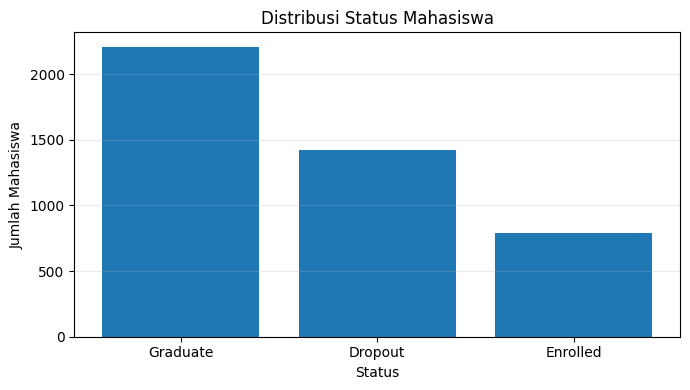

In [4]:
counts = df['Status'].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index.astype(str), counts.values)
ax.set_title('Distribusi Status Mahasiswa')
ax.set_xlabel('Status')
ax.set_ylabel('Jumlah Mahasiswa')
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()

### Exploratory Data Analysis (EDA)

Untuk kebutuhan bisnis, target diubah menjadi indikator biner `Is_Dropout`: 1 jika `Status == Dropout`, dan 0 untuk `Enrolled`/`Graduate`. Pendekatan ini langsung menjawab kebutuhan institusi: **siapa yang perlu diprioritaskan untuk intervensi pencegahan dropout**.

Visualisasi berikut memeriksa faktor finansial dan akademik semester pertama yang relevan sebagai sinyal early warning. Hubungan yang terlihat bersifat **asosiasi/deskriptif**, bukan bukti sebab-akibat.

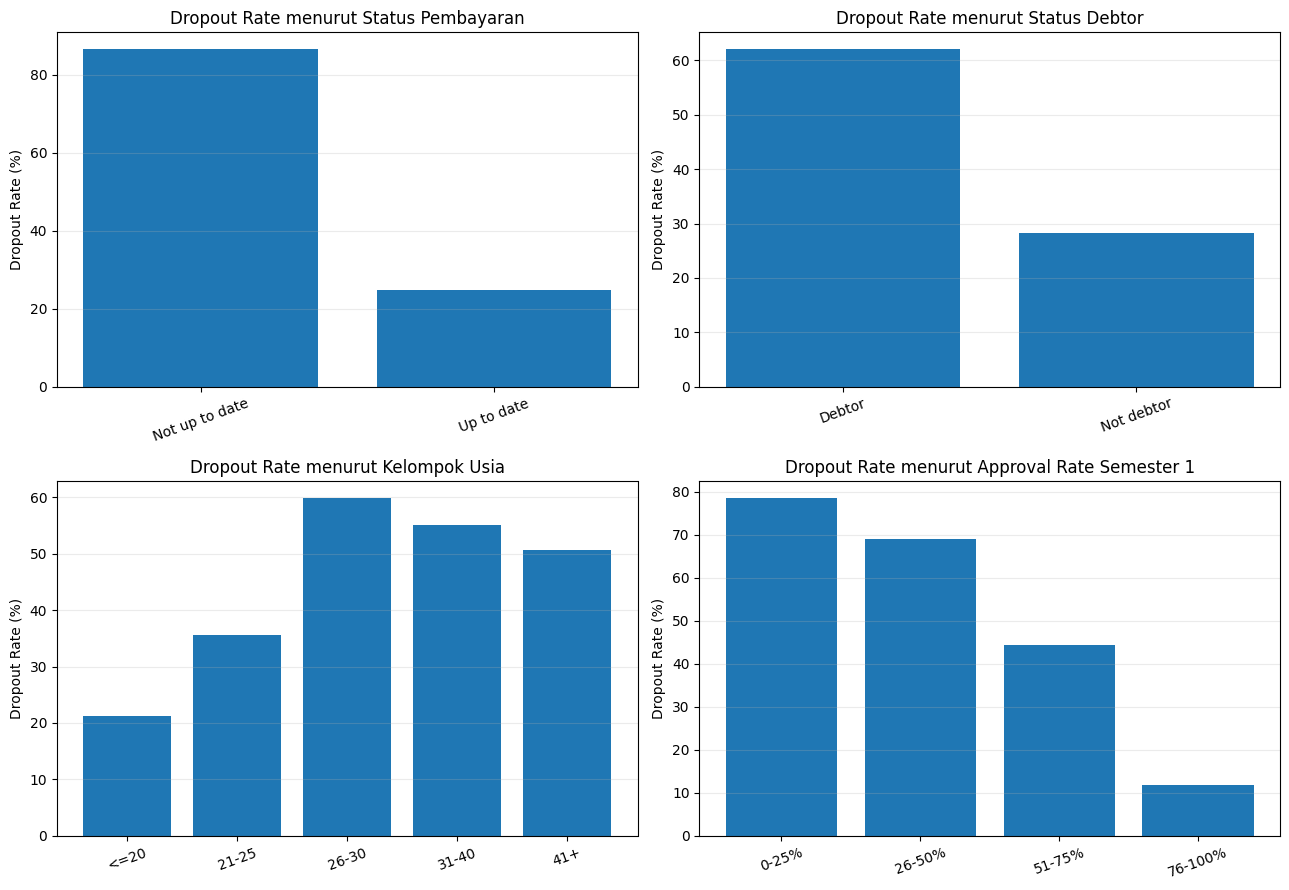

In [5]:
eda = df.copy()
eda['Is_Dropout'] = (eda['Status'] == 'Dropout').astype(int)
eda['Tuition_Status'] = eda['Tuition_fees_up_to_date'].map({1: 'Up to date', 0: 'Not up to date'})
eda['Debtor_Status'] = eda['Debtor'].map({1: 'Debtor', 0: 'Not debtor'})
eda['Scholarship_Status'] = eda['Scholarship_holder'].map({1: 'Scholarship', 0: 'No scholarship'})
eda['AgeGroup'] = pd.cut(
    eda['Age_at_enrollment'],
    bins=[0, 20, 25, 30, 40, 100],
    labels=['<=20', '21-25', '26-30', '31-40', '41+']
)

# Avoid division by zero when no units were enrolled.
eda['FirstSemApprovalRate'] = np.where(
    eda['Curricular_units_1st_sem_enrolled'] > 0,
    eda['Curricular_units_1st_sem_approved'] / eda['Curricular_units_1st_sem_enrolled'],
    0
)
eda['FirstSemApprovalBand'] = pd.cut(
    eda['FirstSemApprovalRate'],
    bins=[-0.01, 0.25, 0.5, 0.75, 1.0],
    labels=['0-25%', '26-50%', '51-75%', '76-100%']
)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_specs = [
    (axes[0,0], 'Tuition_Status', 'Dropout Rate menurut Status Pembayaran'),
    (axes[0,1], 'Debtor_Status', 'Dropout Rate menurut Status Debtor'),
    (axes[1,0], 'AgeGroup', 'Dropout Rate menurut Kelompok Usia'),
    (axes[1,1], 'FirstSemApprovalBand', 'Dropout Rate menurut Approval Rate Semester 1'),
]

for ax, col, title in plot_specs:
    temp = eda.groupby(col, observed=False)['Is_Dropout'].mean().mul(100)
    labels = temp.index.astype(str)
    ax.bar(labels, temp.values)
    ax.set_title(title)
    ax.set_ylabel('Dropout Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

In [6]:
# Tabel ringkas untuk membantu interpretasi EDA.
for col in ['Tuition_Status', 'Debtor_Status', 'Scholarship_Status', 'AgeGroup', 'FirstSemApprovalBand']:
    summary = (
        eda.groupby(col, observed=False)
        .agg(Total=('Is_Dropout', 'size'), Dropout=('Is_Dropout', 'sum'), Dropout_Rate=('Is_Dropout', 'mean'))
        .reset_index()
    )
    summary['Dropout_Rate'] = (summary['Dropout_Rate'] * 100).round(2)
    print()
    print(col)
    display(summary)


Tuition_Status


,Tuition_Status,Total,Dropout,Dropout_Rate
0,Not up to date,528,457,86.55
1,Up to date,3896,964,24.74



Debtor_Status


,Debtor_Status,Total,Dropout,Dropout_Rate
0,Debtor,503,312,62.03
1,Not debtor,3921,1109,28.28



Scholarship_Status


,Scholarship_Status,Total,Dropout,Dropout_Rate
0,No scholarship,3325,1287,38.71
1,Scholarship,1099,134,12.19



AgeGroup


,AgeGroup,Total,Dropout,Dropout_Rate
0,<=20,2551,542,21.25
1,21-25,828,295,35.63
2,26-30,383,229,59.79
3,31-40,437,241,55.15
4,41+,225,114,50.67



FirstSemApprovalBand


,FirstSemApprovalBand,Total,Dropout,Dropout_Rate
0,0-25%,847,665,78.51
1,26-50%,294,203,69.05
2,51-75%,509,226,44.40
3,76-100%,2774,327,11.79


## Data Preparation / Preprocessing

Untuk menjaga prototype tetap mudah digunakan dan sesuai tujuan *early warning*, model hanya memakai data pendaftaran, faktor finansial/demografi, dan performa **semester pertama**. Informasi semester kedua sengaja tidak digunakan agar prediksi dapat dilakukan lebih dini.

Fitur kategorikal di-*one-hot encode*, fitur numerik diimputasi dan distandardisasi untuk Logistic Regression. Pipeline memastikan preprocessing yang sama digunakan saat training dan inference.

In [7]:
FEATURES = [
    'Course',
    'Daytime_evening_attendance',
    'Admission_grade',
    'Displaced',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Gender',
    'Scholarship_holder',
    'Age_at_enrollment',
    'International',
    'Curricular_units_1st_sem_enrolled',
    'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations',
]

CATEGORICAL_FEATURES = [
    'Course', 'Daytime_evening_attendance', 'Displaced', 'Debtor',
    'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'International'
]
NUMERIC_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

X = df[FEATURES].copy()
y = (df['Status'] == 'Dropout').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipe, NUMERIC_FEATURES),
    ('cat', categorical_pipe, CATEGORICAL_FEATURES),
])

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Proporsi dropout train:', round(y_train.mean(), 4))
print('Proporsi dropout test :', round(y_test.mean(), 4))

Train: (3539, 15) | Test: (885, 15)
Proporsi dropout train: 0.3213
Proporsi dropout test : 0.3209


## Modeling

Dua model dibandingkan:
1. **Logistic Regression** sebagai baseline yang sederhana dan interpretatif.
2. **Random Forest** untuk menangkap hubungan non-linear/interaksi antar fitur.

Karena tujuan bisnis memprioritaskan mahasiswa dropout, evaluasi utama menggunakan **F1-score kelas dropout**, dengan recall sebagai metrik penting agar mahasiswa berisiko tidak terlalu banyak terlewat. Ambang probabilitas (threshold) 0,40 digunakan untuk meningkatkan sensitivitas early warning.

In [8]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

THRESHOLD = 0.40
results = []
trained_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= THRESHOLD).astype(int)

    row = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision_Dropout': precision_score(y_test, pred, zero_division=0),
        'Recall_Dropout': recall_score(y_test, pred, zero_division=0),
        'F1_Dropout': f1_score(y_test, pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, proba),
    }
    results.append(row)
    trained_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('F1_Dropout', ascending=False).reset_index(drop=True)
display(results_df.style.format({c: '{:.3f}' for c in results_df.columns if c != 'Model'}))

BEST_MODEL_NAME = results_df.iloc[0]['Model']
best_model = trained_pipelines[BEST_MODEL_NAME]
print('Model terpilih:', BEST_MODEL_NAME)

,Model,Accuracy,Precision_Dropout,Recall_Dropout,F1_Dropout,ROC_AUC
0,Random Forest,0.843,0.720,0.835,0.773,0.902
1,Logistic Regression,0.823,0.675,0.863,0.757,0.904


Model terpilih: Random Forest


## Evaluation

Confusion matrix dan classification report digunakan untuk memahami kesalahan prediksi. Dalam konteks early warning, **false negative** (mahasiswa sebenarnya dropout tetapi diprediksi non-dropout) perlu mendapat perhatian khusus karena mahasiswa tersebut dapat terlewat dari program intervensi.

              precision    recall  f1-score   support

 Non-Dropout       0.92      0.85      0.88       601
     Dropout       0.72      0.83      0.77       284

    accuracy                           0.84       885
   macro avg       0.82      0.84      0.83       885
weighted avg       0.85      0.84      0.85       885



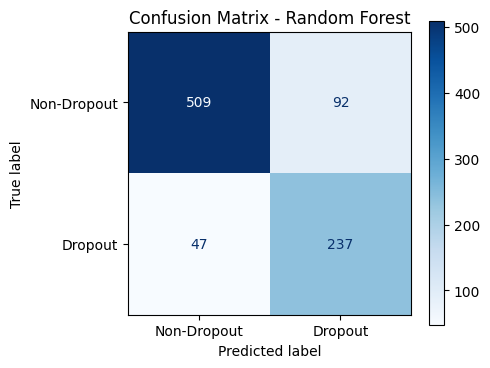

In [9]:
best_proba = best_model.predict_proba(X_test)[:, 1]
best_pred = (best_proba >= THRESHOLD).astype(int)

print(classification_report(y_test, best_pred, target_names=['Non-Dropout', 'Dropout']))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_pred,
    display_labels=['Non-Dropout', 'Dropout'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Confusion Matrix - {BEST_MODEL_NAME}')
plt.tight_layout()
plt.show()

,Feature,Importance
4,num__Curricular_units_1st_sem_approved,0.222118
5,num__Curricular_units_1st_sem_grade,0.166886
1,num__Age_at_enrollment,0.082119
0,num__Admission_grade,0.081704
3,num__Curricular_units_1st_sem_evaluations,0.067015
30,cat__Tuition_fees_up_to_date_0,0.059503
31,cat__Tuition_fees_up_to_date_1,0.059133
2,num__Curricular_units_1st_sem_enrolled,0.036655
34,cat__Scholarship_holder_0,0.021674
35,cat__Scholarship_holder_1,0.021419


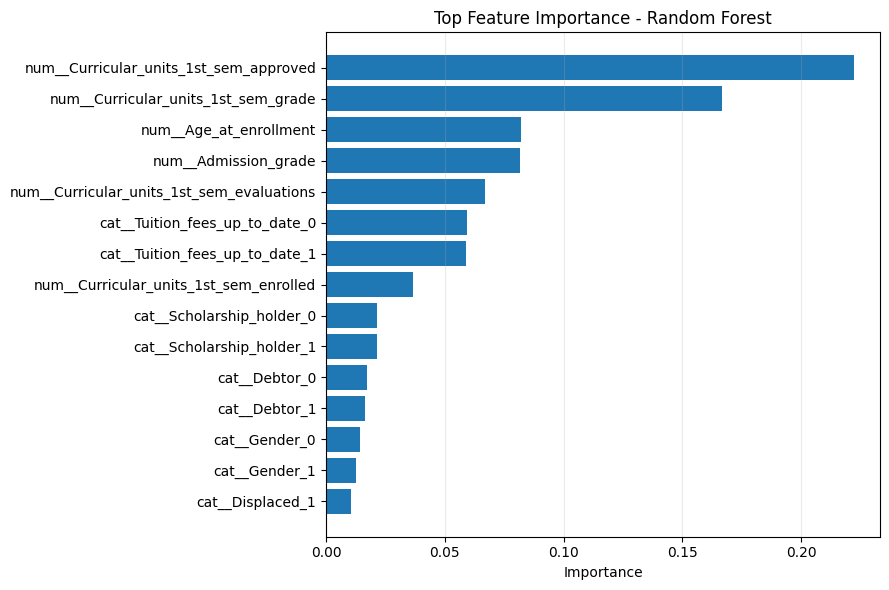

In [10]:
# Feature importance / coefficient magnitude untuk interpretasi model.
pre = best_model.named_steps['preprocessor']
feature_names = pre.get_feature_names_out()
est = best_model.named_steps['model']

if hasattr(est, 'feature_importances_'):
    importance = est.feature_importances_
elif hasattr(est, 'coef_'):
    importance = np.abs(est.coef_[0])
else:
    importance = np.zeros(len(feature_names))

fi = (
    pd.DataFrame({'Feature': feature_names, 'Importance': importance})
    .sort_values('Importance', ascending=False)
    .head(15)
)

display(fi)

fig, ax = plt.subplots(figsize=(9, 6))
plot_df = fi.sort_values('Importance', ascending=True)
ax.barh(plot_df['Feature'], plot_df['Importance'])
ax.set_title(f'Top Feature Importance - {BEST_MODEL_NAME}')
ax.set_xlabel('Importance')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## Menyimpan Model dan Data Dashboard

Cell berikut membuat artefak yang dibutuhkan untuk submission:
- `model/dropout_model.joblib` — pipeline preprocessing + model + metadata.
- `data/dashboard_student_performance.csv` — data yang sudah diperkaya untuk Looker Studio.

**Pastikan cell ini berhasil dijalankan sebelum membuat ZIP submission.**

In [11]:
Path('model').mkdir(exist_ok=True)
Path('data').mkdir(exist_ok=True)

artifact = {
    'model': best_model,
    'threshold': THRESHOLD,
    'features': FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'numeric_features': NUMERIC_FEATURES,
    'model_name': BEST_MODEL_NAME,
}
joblib.dump(artifact, 'model/dropout_model.joblib')
print('Model tersimpan: model/dropout_model.joblib')

COURSE_MAP = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising & Marketing Management',
    9773: 'Journalism & Communication',
    9853: 'Basic Education',
    9991: 'Management (evening)',
}

dash = df.copy()
dash.insert(0, 'StudentId', np.arange(1, len(dash) + 1))
dash['Is_Dropout'] = (dash['Status'] == 'Dropout').astype(int)
dash['CourseName'] = dash['Course'].map(COURSE_MAP).fillna(dash['Course'].astype(str))
dash['AttendanceType'] = dash['Daytime_evening_attendance'].map({1: 'Daytime', 0: 'Evening'})
dash['TuitionStatus'] = dash['Tuition_fees_up_to_date'].map({1: 'Up to date', 0: 'Not up to date'})
dash['DebtorStatus'] = dash['Debtor'].map({1: 'Debtor', 0: 'Not debtor'})
dash['ScholarshipStatus'] = dash['Scholarship_holder'].map({1: 'Scholarship', 0: 'No scholarship'})
dash['GenderLabel'] = dash['Gender'].map({1: 'Male', 0: 'Female'})
dash['AgeGroup'] = pd.cut(
    dash['Age_at_enrollment'], [0, 20, 25, 30, 40, 100],
    labels=['<=20', '21-25', '26-30', '31-40', '41+']
).astype(str)
dash['FirstSemApprovalRate'] = np.where(
    dash['Curricular_units_1st_sem_enrolled'] > 0,
    dash['Curricular_units_1st_sem_approved'] / dash['Curricular_units_1st_sem_enrolled'], 0
)
dash['FirstSemApprovalBand'] = pd.cut(
    dash['FirstSemApprovalRate'], [-0.01, 0.25, 0.5, 0.75, 1.0],
    labels=['0-25%', '26-50%', '51-75%', '76-100%']
).astype(str)

dashboard_cols = [
    'StudentId', 'Status', 'Is_Dropout', 'Course', 'CourseName', 'AttendanceType',
    'TuitionStatus', 'DebtorStatus', 'ScholarshipStatus', 'GenderLabel',
    'Age_at_enrollment', 'AgeGroup', 'Admission_grade',
    'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations',
    'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade',
    'Curricular_units_1st_sem_without_evaluations',
    'FirstSemApprovalRate', 'FirstSemApprovalBand'
]
dash[dashboard_cols].to_csv('data/dashboard_student_performance.csv', index=False)
print('Dashboard data tersimpan: data/dashboard_student_performance.csv')

Model tersimpan: model/dropout_model.joblib
Dashboard data tersimpan: data/dashboard_student_performance.csv


## Conclusion

Proyek ini menghasilkan sistem **early warning dropout** untuk Jaya Jaya Institut dengan menggabungkan analisis deskriptif, business dashboard, dan prototype machine learning. Dataset berisi **4.424 mahasiswa** dengan distribusi **2.209 Graduate**, **1.421 Dropout**, dan **794 Enrolled**. Dengan demikian, dropout rate keseluruhan adalah sekitar **32,12%**.

Beberapa pola deskriptif yang paling kuat pada data adalah:
- Mahasiswa dengan biaya kuliah **tidak up to date** memiliki dropout rate **86,55%**, dibanding **24,74%** pada mahasiswa dengan pembayaran up to date.
- Mahasiswa berstatus **debtor** memiliki dropout rate **62,03%**, dibanding **28,28%** pada non-debtor.
- Mahasiswa **tanpa beasiswa** memiliki dropout rate **38,71%**, sedangkan penerima beasiswa **12,19%**.
- Approval rate semester pertama sangat informatif: kelompok **0-25%** memiliki dropout rate **78,51%**, sedangkan kelompok **76-100%** hanya **11,79%**.

Untuk kebutuhan machine learning, target dipetakan menjadi **Dropout (1) vs Non-Dropout (0)** dan model hanya menggunakan data yang tersedia paling lambat setelah semester pertama agar tetap relevan sebagai early warning. Dengan split train-test 80:20, random state 42, serta threshold early warning **0,40**, model terbaik pada perbandingan ini adalah **Random Forest** dengan hasil pada test set:

- **Accuracy:** 84,29%
- **Precision kelas Dropout:** 72,04%
- **Recall kelas Dropout:** 83,45%
- **F1-score kelas Dropout:** 77,32%
- **ROC-AUC:** 90,23%
- **Confusion matrix:** TN=509, FP=92, FN=47, TP=237

Recall dropout yang relatif tinggi sesuai dengan tujuan bisnis early warning karena mengurangi jumlah mahasiswa dropout yang terlewat dari daftar intervensi. Namun, prediksi tetap digunakan sebagai **decision-support**, bukan keputusan otomatis terhadap mahasiswa.

### Rekomendasi Action Items
1. Prioritaskan monitoring mahasiswa dengan biaya kuliah tidak *up to date* atau status debtor, lalu arahkan ke dukungan finansial yang sesuai.
2. Buat trigger intervensi akademik untuk mahasiswa dengan approval rate semester pertama rendah melalui tutoring, konseling akademik, dan review beban studi.
3. Gunakan tier risiko dari prototype (rendah/sedang/tinggi) sebagai antrean prioritas follow-up dosen wali/konselor, bukan sebagai hukuman atau keputusan final.
4. Pantau performa model secara berkala dan lakukan retraining ketika recall/F1 menurun atau karakteristik mahasiswa berubah.
5. Gabungkan sinyal model dengan informasi kualitatif dari dosen wali/konselor agar intervensi tetap adil dan kontekstual.
